In [1]:
### Important note: For some patients, they transferred to the floor in between daily CAM assessments. In those cases,
#   their last ICU day, and floor day 1, are treated as the same day. By convention, the label for that day is the last ICU
#   day, and "floor day 1" does not exist in analysis. Floor days 2-7 would then represent the 6 floor days to evaluate
#   delirium-free days.

import pandas as pd
import numpy as np
import scipy.stats
import datetime as dt
import time
import csv
import os
import shutil
import matplotlib.pyplot as plt
import datetime as dt
import math

today = dt.datetime.now().strftime("%Y-%m-%d")
#current_version = today
current_version = '2020-01-23'

# get CAM data
mad3_path = "Z:/Projects/ICU_SLEEP_STUDY/data/"
subjects_path = mad3_path + "enrolled_subjects/"

cam_filename = 'Z:/Projects/ICU_SLEEP_STUDY/data/cam_full_' + current_version + '.csv' #from CAM_full report in redcap
cam_df = pd.read_csv(cam_filename)

withdrawals_filename = 'Z:/Projects/ICU_SLEEP_STUDY/data/withdrawals_' + current_version + '.csv' #make withdrawal report on redcap
withdrawals_df = pd.read_csv(withdrawals_filename)

# get current data dictionary
data_dict_filename = 'Z:/Projects/ICU_SLEEP_STUDY/data/data_dictionary_' + '2019-04-24' +'.csv'
dd_df_full = pd.read_csv(data_dict_filename)

In [3]:
cam_df.head()

,study_id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,camncamicu_staff,cam_yn,cam_other,camcamicu_assess_staff,cam_version,camncamicu_crtdate,...,cams_3,cams_4,cams_5,cams_6,cams_7,cams_8,cams_9,cams_10,cams_total,cam_camicu_complete
0,1,icu_day_1_pm_arm_1,NaN,NaN,3.0,1.0,NaN,4.0,NaN,2018-06-06 16:51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1,icu_day_2_am_arm_1,NaN,NaN,3.0,1.0,NaN,4.0,NaN,2018-06-07 10:30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,1,icu_day_2_pm_arm_1,NaN,NaN,3.0,1.0,NaN,4.0,NaN,2018-06-07 17:30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,1,icu_day_3_am_arm_1,NaN,NaN,3.0,1.0,NaN,2.0,NaN,2018-06-08 11:07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,1,floor_day_1_pm_arm_1,NaN,NaN,3.0,1.0,NaN,4.0,NaN,2018-06-08 17:19,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1


In [2]:
## get IDs of subjects withdrawn 
withdrawn_df = withdrawals_df.loc[withdrawals_df['withdrawal_drugtime'] == 1].reset_index() #update based on new w/d system
withdrawn_ids = withdrawn_df.study_id.values

# choose subjects to analyze
pre_exclude_subject_list = range(1,201)
exclusion_list = list(withdrawn_ids) + ['162', '199'] # add 162 manually
subject_list = [ii for ii in pre_exclude_subject_list if str(ii) not in exclusion_list]
print(subject_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 23, 24, 25, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 194, 195, 196, 197, 198, 200]


In [4]:
# creates dictionary of CAM-S severity rating to variable in cams_df
all_cam_S_vars = ['study_id','redcap_event_name', 'camncamicu_crtdate', 'cams_1', 'cams_2', 'cams_3', 'cams_4','cams_5',
                  'cams_6','cams_7','cams_8','cams_9', 'cams_10', 'cams_total']

cam_S_dd = {'eval_datetime': 'camncamicu_crtdate', 'acute_onset':'cams_1', 'inattention':'cams_2', 'disorganized':'cams_3', 
            'LOC':'cams_4','disorientation':'cams_5', 'memory':'cams_6', 'perceptual':'cams_7', 'agitation':'cams_8', 
            'retardation':'cams_9', 'sleep_wake':'cams_10', 'CAM-S total':'cams_total'}

cam_icu_vars = ['study_id','redcap_event_name', 'camncamicu_crtdate', 'camncamicu_f1', 'camncamicu_f2', 'camncamicu_f3', 
                'camncamicu_f4', 'saveahaart_posneg', 'disorganized_posneg', 'cams_total']

addit_day_dict = {'additional_icu_day_arm_1': 8,  'additional_icu_day_arm_1b': 8, 
                  'additional_icu_day_arm_1c': 9,  'additional_icu_day_arm_1d': 9,
                  'additional_icu_day_arm_1e': 10, 'additional_icu_day_arm_1f': 10,
                  'additional_icu_day_arm_1g': 11, 'additional_icu_day_arm_1h': 11,
                  'additional_icu_day_arm_1i': 12, 'additional_icu_day_arm_1j': 12,
                  'additional_icu_day_arm_1k': 13, 'additional_icu_day_arm_1l': 13,
                  'additional_icu_day_arm_1m': 14, 'additional_icu_day_arm_1n': 14}

In [8]:
# Version 1: Calculate delirious days based on CAM-ICU
cam_icu_df = cam_df[cam_icu_vars]

icu_cam_icu_scores   = np.zeros(shape=(len(pre_exclude_subject_list),14)) # expanded up to 14 days
floor_cam_icu_scores = np.zeros(shape=(len(pre_exclude_subject_list),7))

icu_days_included   = np.zeros(shape=(len(pre_exclude_subject_list),14)) # expanded up to 14 days
floor_days_included = np.zeros(shape=(len(pre_exclude_subject_list),7))

# added to handle "first 14 days" issue
icu_days_happened   = np.zeros(shape=(len(pre_exclude_subject_list),14)) # expanded up to 14 days
floor_days_happened = np.zeros(shape=(len(pre_exclude_subject_list),7))

# final numpy array of interest
cam_icu_scores_upto14 = np.zeros(shape=(len(pre_exclude_subject_list),14))
days_included_upto14 = np.zeros(shape=(len(pre_exclude_subject_list),14)) # expanded up to 14 days

for subject in subject_list:
    cam_icu_indiv_df = cam_icu_df.loc[cam_icu_df['study_id'] == str(subject)]
    icu_CAM_icu_totals = [0] * 14
    floor_CAM_icu_totals = [0] * 7
    
    CAM_icu_totals = [0]*14

    
    last_icu_date = ''
    for index, cam in cam_icu_indiv_df.iterrows():
        
        if (not (  type(cam[cam_S_dd['eval_datetime']]) is str  ) ):# or math.isnan(cam['cams_total']):
            continue # missing data, skip
            
        eval_datetime = dt.datetime.strptime(cam[cam_S_dd['eval_datetime']], '%Y-%m-%d %H:%M')
        eval_date = eval_datetime.date()
        
        # can't calculate cam ICU
        if math.isnan(cam['camncamicu_f1']) or math.isnan(cam['camncamicu_f3']) or math.isnan(cam['camncamicu_f2']) or math.isnan(cam['camncamicu_f4']): # if score is missing, set to -1 by convention
            score = float(-1)
        else:
            altered_and_save = int(cam['camncamicu_f1']) == 1 and int(cam['camncamicu_f2']) == 1
            loc_or_disorg = int(cam['camncamicu_f3' ]) == 1 or int(cam['camncamicu_f4']) == 1
            if altered_and_save and loc_or_disorg:
                score = 1
            else:
                score = 0
        
        # set event type
        event = cam['redcap_event_name']
        event_split = event.split('_')
        event_where = event_split[0]  # 'floor' or 'icu'
        
        if event_where == 'additional' and event in addit_day_dict: # this is an additional icu day between 8 and 14
            last_icu_date = eval_date
            addit_icu_day = int(addit_day_dict[event]) # icu day from 8-14
            
            icu_days_happened[subject-1, addit_icu_day-1] = 1 # this is 1 regardless of score
            if score >= float(0):
                icu_days_included[subject-1, addit_icu_day-1] = 1 # include this icu day in analysis since data exists
            
            # replace value of CAM-S for this ICU day -- use zero indexing, so subtract one
            if  score > icu_cam_icu_scores[subject-1, addit_icu_day-1]:
                icu_cam_icu_scores[subject-1, addit_icu_day-1] = score
                
            
        if not event_where == 'additional': 
            event_day = int(event_split[2]) # 'days 1-7'
            event_time = event_split[3] # am or pm, not needed here (yet)
            
        
        
        if event_where == 'icu':    # this is an icu day
            last_icu_date = eval_date
            
            icu_days_happened[subject-1, event_day-1] = 1 # this is 1 regardless of score
            if score >= float(0):
                icu_days_included[subject-1, event_day-1] = 1 # include this icu day in analysis since data exists
            
            # replace value of CAM-S for this ICU day -- use zero indexing, so subtract one
            if  score > icu_cam_icu_scores[subject-1, event_day-1]:
                icu_cam_icu_scores[subject-1, event_day-1] = score
                
        else: # this is a floor day
            
            # skip if last icu day and floor day 1 are the same
            if event_day == 1 and eval_date == last_icu_date:
                floor_days_included[subject-1, event_day-1] = 0 # not really a necessary line but is conceptually helpful
                floor_days_happened[subject-1, event_day-1] = 0
                continue # move on to next event
            
            else: 
                
                floor_days_happened[subject-1, event_day-1] = 1 # this is 1 regardless of score
                if score >= float(0):
                    floor_days_included[subject-1, event_day-1] = 1 # include this floor day in analysis since data exists
                    
                if  score > floor_cam_icu_scores[subject-1, event_day-1]:
                    floor_cam_icu_scores[subject-1, event_day-1] = score
                    
    last_icu_dex   = np.argwhere(icu_days_happened[subject-1,:] == 1)[-1][0]
    if len(np.argwhere(floor_days_happened[subject-1,:] == 1)) > 0:
        last_floor_dex = np.argwhere(floor_days_happened[subject-1,:] == 1)[-1][0]
        
        # floor day 1 is the same as last icu day. Need to skip it
        if floor_days_happened[subject-1,0] == 0:
            skip_f1 = True
        else:
            skip_f1 = False
            
    
    ### based on icu and floor days, create up-to-14 day arrays
    cam_icu_scores_upto14[subject-1, 0:last_icu_dex+1] =  icu_cam_icu_scores[subject-1, 0:last_icu_dex+1]
    days_included_upto14[subject-1, 0:last_icu_dex+1] = icu_days_included[subject-1, 0:last_icu_dex+1]
    if last_icu_dex + 1 < 14 and len(np.argwhere(floor_days_included[subject-1,:] == 1)) > 0:
        
        if not skip_f1:
            cam_icu_scores_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex + 1, 14)] = floor_cam_icu_scores[subject-1, 0:min(7, (14 - last_icu_dex - 1))]
            days_included_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex + 1, 14)] = floor_days_included[subject-1, 0:min(7, (14 - last_icu_dex - 1))]
        else:
            cam_icu_scores_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex, 14)] = floor_cam_icu_scores[subject-1, 1:min(7, (14 - last_icu_dex))]
            days_included_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex, 14)] = floor_days_included[subject-1, 1:min(7, (14 - last_icu_dex))]

# this is raw delirium days -- ignores missing data
icu_delirious_days = [0]*len(pre_exclude_subject_list)
floor_delirious_days = [0]*len(pre_exclude_subject_list)

# this is delirium-free days -- at least one observation made. If highest CAM-s below threshold, not delirious
icu_delirium_free_days = [0]*len(pre_exclude_subject_list)
floor_delirium_free_days = [0]*len(pre_exclude_subject_list)

for subject in subject_list:
    for icu_day in range(1,8): # one-index here and subtract one, in order to be consistent
        
        if icu_days_included[subject-1,icu_day-1] == 1: # there was at least one observation
            if icu_cam_icu_scores[subject-1,icu_day-1] > 0:
                icu_delirious_days[subject-1] += 1
            else:
                icu_delirium_free_days[subject-1] += 1
            
    for floor_day in range(1,8):
        
        if floor_days_included[subject-1,floor_day-1] == 1:
            if floor_cam_icu_scores[subject-1,floor_day-1] > 0:
                floor_delirious_days[subject-1] += 1
            else:
                floor_delirium_free_days[subject-1] += 1

# normalized delirium free days in tuple format
icu_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)
floor_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)

icu_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)
floor_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)

for subject in subject_list:
    observed_icu_days = sum(icu_days_included[subject-1,:])
    observed_floor_days = sum(floor_days_included[subject-1,:])
    
    icu_tuple1 = int(icu_delirium_free_days[subject-1])
    icu_delirious_tuple1 = int(icu_delirious_days[subject-1])
    icu_tuple2 = int(observed_icu_days)
    floor_tuple1 = int(floor_delirium_free_days[subject-1])
    floor_delirious_tuple1 = int(floor_delirious_days[subject-1])
    floor_tuple2 = int(observed_floor_days)
    
    icu_delirium_free_tuples[subject-1] = (icu_tuple1,icu_tuple2)
    floor_delirium_free_tuples[subject-1] = (floor_tuple1,floor_tuple2)
    
    icu_delirious_tuples[subject-1] = (icu_delirious_tuple1,icu_tuple2)
    floor_delirious_tuples[subject-1] = (floor_delirious_tuple1,floor_tuple2)
    
# calculate total included days for each

total_days_included = [0] * len(pre_exclude_subject_list)

for subject in subject_list:
    total_days = floor_delirious_days[subject-1] + icu_delirious_days[subject-1] + \
                 floor_delirium_free_days[subject-1] + icu_delirium_free_days[subject-1]
    total_days_included[subject-1] = total_days
    

In [9]:
# Version 2: Calculate delirious days based on raw CAM-S scores -- not normalized or augmented by nursing, and ignoring
# CAM-evaluated days in ICU beyond 7
cam_S_df = cam_df[all_cam_S_vars]

# Creates numpy arrays with the following structure: the first array is for the first seven days of the ICU (columns), 
# and represent the *highest* CAM-S total recorded for that day. The rows are subjects.
# The next list represents the first seven floor days (columns). 
# For patients who transferred in the middle of the day, the CAM-S value for floor day 1 is set to 0
icu_cam_S2_scores   = np.zeros(shape=(len(pre_exclude_subject_list),14))
floor_cam_S2_scores = np.zeros(shape=(len(pre_exclude_subject_list),7))

# binary whether this for each day a patient was available and data was collected
# 1= data was collected, 0= ignore this day when computing denominators for measures of delirium days

icu_days_included   = np.zeros(shape=(len(pre_exclude_subject_list),14))
floor_days_included = np.zeros(shape=(len(pre_exclude_subject_list),7))

# added to handle "first 14 days" issue
icu_days_happened   = np.zeros(shape=(len(pre_exclude_subject_list),14)) # expanded up to 14 days
floor_days_happened = np.zeros(shape=(len(pre_exclude_subject_list),7))

# final numpy array of interest
cam_S2_scores_upto14 = np.zeros(shape=(len(pre_exclude_subject_list),14))
days_included_upto14  = np.zeros(shape=(len(pre_exclude_subject_list),14)) # expanded up to 14 days

# iterate through subjects - calculate delirium-free days
for subject in subject_list:
    cam_S_indiv_df = cam_S_df.loc[cam_S_df['study_id'] == str(subject)]
    
    # Creates a list with the following structure: the first list is for the first seven days of the ICU, 
    # and represent the *highest* CAM-S total recorded for that day. The next list represents the first seven
    # floor days. For patients who transferred in the middle of the day, the CAM-S value for floor day 1 is set to 0
    icu_CAM_S_totals = [0] * 7
    floor_CAM_S_totals = [0] * 7
    #num_icu_delirium_days = 0
    #num_floor_delirium_days = 0
    #avg_cam_s_total = 0
    
    #cam_s_total_series = []
    
    # assign floor 1 values to last ICU if true, and skip floor 1 data pt
    last_icu_date = ''
    #iterate through assessments
    for index, cam in cam_S_indiv_df.iterrows():

        if not (  type(cam[cam_S_dd['eval_datetime']]) is str  ):
            continue # missing data, skip
            
        eval_datetime = dt.datetime.strptime(cam[cam_S_dd['eval_datetime']], '%Y-%m-%d %H:%M')
        eval_date = eval_datetime.date()
        score = float(cam['cams_total'])        
        
        if math.isnan(score): # if score is missing, set to -1 by convention
            score = float(-1)
        else:
            # calculate if inattentive, acute changes, and another cognitive impairment. If not, set score back to zero
            
            try:
                attention = int(cam[cam_S_dd['inattention']]) >= 1
                acute = int(cam[cam_S_dd['acute_onset']]) >= 1
            except:
                attention = False
                acute = False
            
            # other cognitive
            try:
                disorganized = int(cam[cam_S_dd['disorganized']]) >= 1
            except:
                disorganized = False
            try:
                LOC = int(cam[cam_S_dd['LOC']]) >= 1
            except:
                LOC = False
            try:
                disoriented = int(cam[cam_S_dd['disorientation']]) >= 1
            except:
                disoriented = False
            try:
                memory = int(cam[cam_S_dd['memory']]) >= 1
            except:
                memory = False
            try:
                perceptual = int(cam[cam_S_dd['perceptual']]) >= 1
            except:
                perceptual = False
            try:
                agitation = int(cam[cam_S_dd['agitation']]) >= 1
            except:
                agitation = False
            try:
                retardation = int(cam[cam_S_dd['retardation']]) >= 1
            except:
                retardation = False
                
            cog_impaired = disorganized or LOC or disoriented or memory or perceptual or agitation or retardation
            
            if not (attention and acute and cog_impaired):
                # they're not delirious. Reset score to zero
                score = 0
        
        # set event type
        event = cam['redcap_event_name']
        event_split = event.split('_')
        event_where = event_split[0]  # 'floor' or 'icu'
            
        if event_where == 'additional' and event in addit_day_dict: # this is an additional icu day between 8 and 14
            last_icu_date = eval_date
            addit_icu_day = int(addit_day_dict[event]) # icu day from 8-14
            
            icu_days_happened[subject-1, addit_icu_day-1] = 1 # this is 1 regardless of score
            if score >= float(0):
                icu_days_included[subject-1, addit_icu_day-1] = 1 # include this icu day in analysis since data exists
            
            # replace value of CAM-S for this ICU day -- use zero indexing, so subtract one
            if  score > icu_cam_S2_scores[subject-1, addit_icu_day-1]:
                icu_cam_S2_scores[subject-1, addit_icu_day-1] = score
        
        if not event_where == 'additional':
            event_day = int(event_split[2]) # 'days 1-7'
            event_time = event_split[3] # am or pm, not needed here (yet)
        
        if event_where == 'icu':    # this is an icu day
            last_icu_date = eval_date
            
            icu_days_happened[subject-1, event_day-1] = 1 # this is 1 regardless of score
            if score >= float(0):
                icu_days_included[subject-1, event_day-1] = 1 # include this icu day in analysis since data exists
            
            # replace value of CAM-S for this ICU day -- use zero indexing, so subtract one
            if  score > icu_cam_icu_scores[subject-1, event_day-1]:
                icu_cam_S2_scores[subject-1, event_day-1] = score
                
        else: # this is a floor day
            
            # skip if last icu day and floor day 1 are the same
            if event_day == 1 and eval_date == last_icu_date:
                floor_days_included[subject-1, event_day-1] = 0 # not really a necessary line but is conceptually helpful
                floor_days_happened[subject-1, event_day-1] = 0
                continue # move on to next event
            
            else: 
                
                floor_days_happened[subject-1, event_day-1] = 1 # this is 1 regardless of score
                if score >= float(0):
                    floor_days_included[subject-1, event_day-1] = 1 # include this floor day in analysis since data exists
                    
                if  score > floor_cam_S2_scores[subject-1, event_day-1]:
                    floor_cam_S2_scores[subject-1, event_day-1] = score
                    
    last_icu_dex   = np.argwhere(icu_days_happened[subject-1,:] == 1)[-1][0]
    if len(np.argwhere(floor_days_happened[subject-1,:] == 1)) > 0:
        last_floor_dex = np.argwhere(floor_days_happened[subject-1,:] == 1)[-1][0]
        
        # floor day 1 is the same as last icu day. Need to skip it
        if floor_days_happened[subject-1,0] == 0:
            skip_f1 = True
        else:
            skip_f1 = False
            
    
    ### based on icu and floor days, create up-to-14 day arrays
    cam_S2_scores_upto14[subject-1, 0:last_icu_dex+1] =  icu_cam_S2_scores[subject-1, 0:last_icu_dex+1]
    days_included_upto14[subject-1, 0:last_icu_dex+1] = icu_days_included[subject-1, 0:last_icu_dex+1]
    if last_icu_dex + 1 < 14 and len(np.argwhere(floor_days_included[subject-1,:] == 1)) > 0:
        
        if not skip_f1:
            cam_S2_scores_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex + 1, 14)] = floor_cam_S2_scores[subject-1, 0:min(7, (14 - last_icu_dex - 1))]
            days_included_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex + 1, 14)] = floor_days_included[subject-1, 0:min(7, (14 - last_icu_dex - 1))]
        else:
            cam_S2_scores_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex, 14)] = floor_cam_S2_scores[subject-1, 1:min(7, (14 - last_icu_dex))]
            days_included_upto14[subject-1,(last_icu_dex + 1):min(7 + last_icu_dex, 14)] = floor_days_included[subject-1, 1:min(7, (14 - last_icu_dex))]

# CAM scores are tabulated. Compute delirium-free days
CAM_S_thresh = 3 # delirium is anything greater than this. Equal to is non-delirious

# # this is raw delirium days -- ignores missing data
# icu_delirious_days = [0]*len(pre_exclude_subject_list)
# floor_delirious_days = [0]*len(pre_exclude_subject_list)

# # this is delirium-free days -- at least one observation made. If highest CAM-s below threshold, not delirious
# icu_delirium_free_days = [0]*len(pre_exclude_subject_list)
# floor_delirium_free_days = [0]*len(pre_exclude_subject_list)

# for subject in subject_list:
#     for icu_day in range(1,8): # one-index here and subtract one, in order to be consistent
        
#         if icu_days_included[subject-1,icu_day-1] == 1: # there was at least one observation
#             if icu_cam_S2_scores[subject-1,icu_day-1] > CAM_S_thresh:
#                 icu_delirious_days[subject-1] += 1
#             else:
#                 icu_delirium_free_days[subject-1] += 1
            
#     for floor_day in range(1,8):
        
#         if floor_days_included[subject-1,floor_day-1] == 1:
#             if floor_cam_S2_scores[subject-1,floor_day-1] > CAM_S_thresh:
#                 floor_delirious_days[subject-1] += 1
#             else:
#                 floor_delirium_free_days[subject-1] += 1

# # normalized delirium free days in tuple format
# icu_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)
# floor_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)

# icu_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)
# floor_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)

# for subject in subject_list:
#     observed_icu_days = sum(icu_days_included[subject-1,:])
#     observed_floor_days = sum(floor_days_included[subject-1,:])
    
#     icu_tuple1 = int(icu_delirium_free_days[subject-1])
#     icu_delirious_tuple1 = int(icu_delirious_days[subject-1])
#     icu_tuple2 = int(observed_icu_days)
#     floor_tuple1 = int(floor_delirium_free_days[subject-1])
#     floor_delirious_tuple1 = int(floor_delirious_days[subject-1])
#     floor_tuple2 = int(observed_floor_days)
    
#     icu_delirium_free_tuples[subject-1] = (icu_tuple1,icu_tuple2)
#     floor_delirium_free_tuples[subject-1] = (floor_tuple1,floor_tuple2)
    
#     icu_delirious_tuples[subject-1] = (icu_delirious_tuple1,icu_tuple2)
#     floor_delirious_tuples[subject-1] = (floor_delirious_tuple1,floor_tuple2)


0.18478260869565216


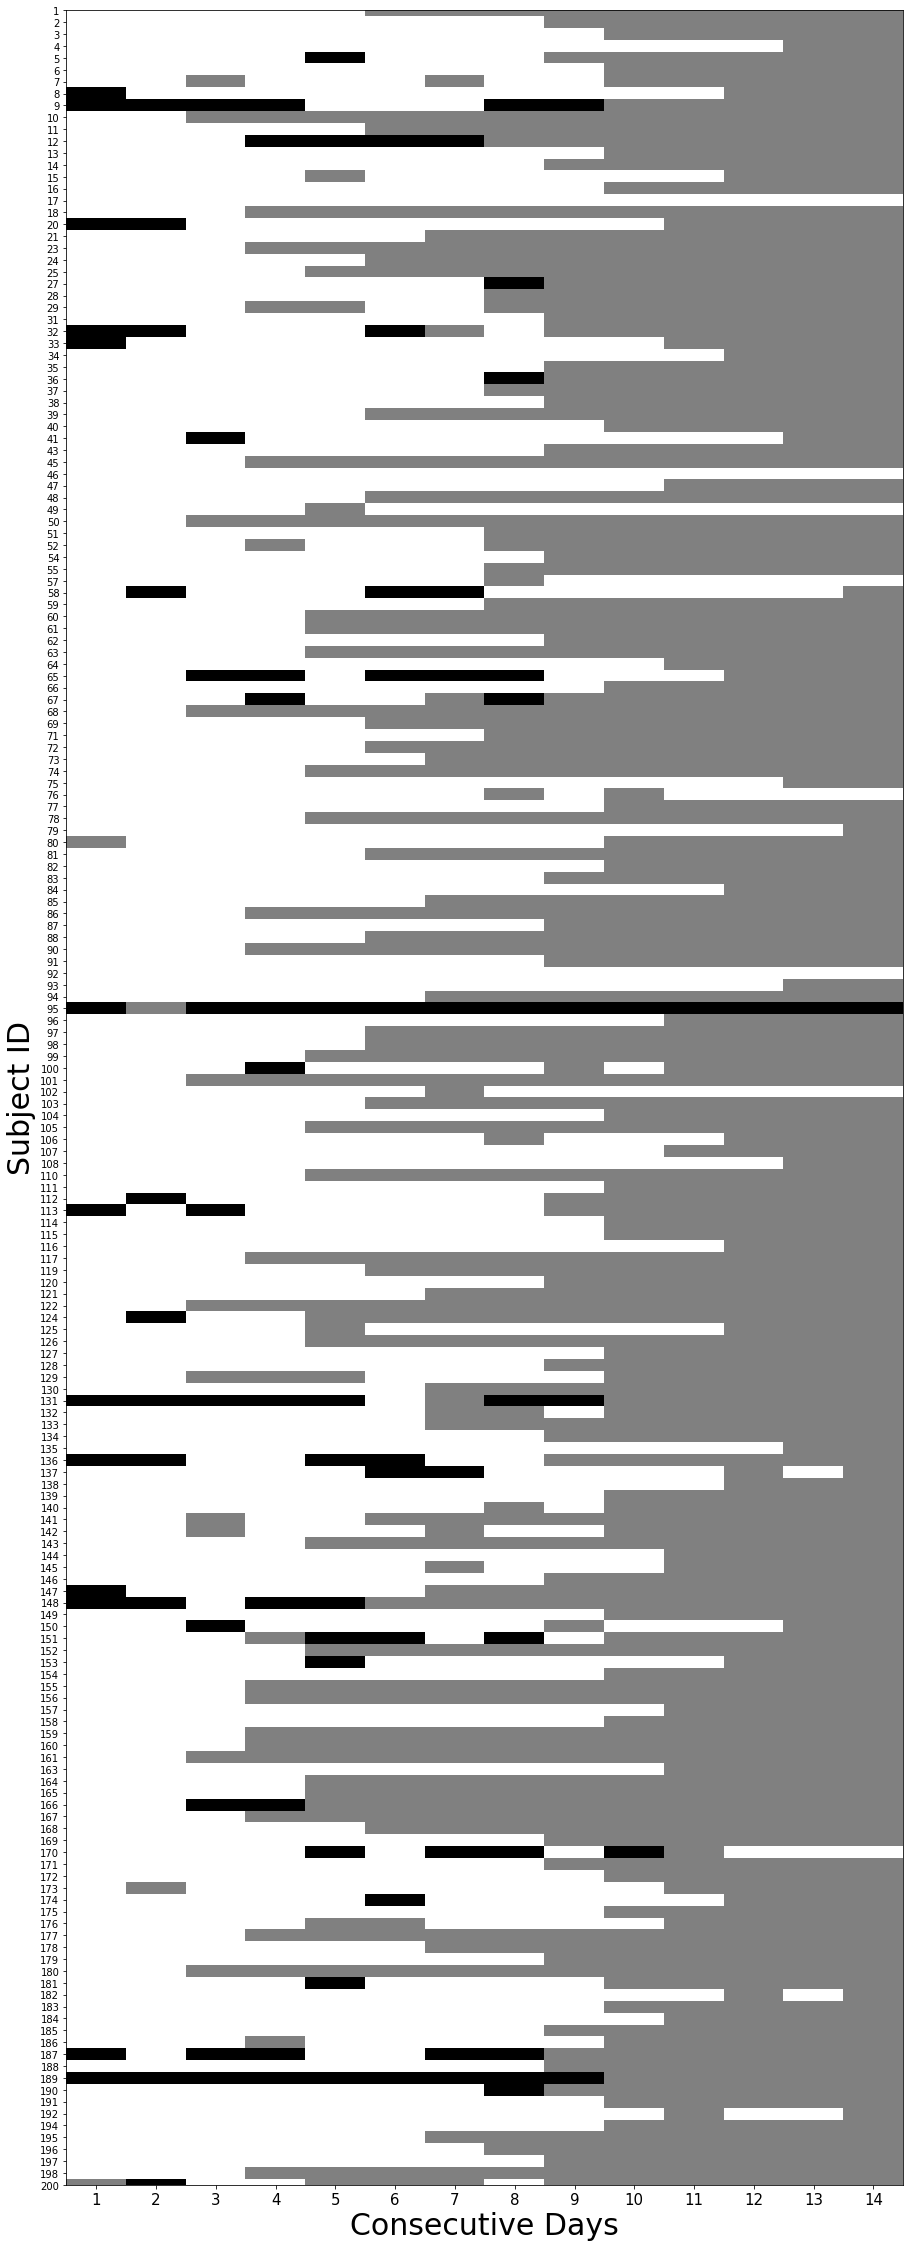

In [10]:
### Swimmer plots - delirium from CAM ICU
from matplotlib import colors

swimmer_CAMICU_full = cam_icu_scores_upto14 + (days_included_upto14 - 1)
swimmer_CAMICU_enrolled = swimmer_CAMICU_full[np.asarray(subject_list)-1,:]

num_days_assessed = np.sum(days_included_upto14[np.asarray(subject_list)-1,:], axis = 1)

num_days_not_assessed_delirious = np.sum( (cam_icu_scores_upto14[np.asarray(subject_list)-1,:] == 0).astype(int), axis = 1)
num_days_assessed_delirious = np.sum( (cam_icu_scores_upto14[np.asarray(subject_list)-1,:] >= 1).astype(int), axis = 1)

num_days_happened = []
DFDs = []
ii = 0
for subject in subject_list:
    
    days_happened = list(np.flatnonzero(days_included_upto14[subject - 1, :]))[-1] + 1
    num_days_happened.append(  days_happened )
    
    DFDs.append(num_days_assessed[ii] - num_days_assessed_delirious[ii])
    #DFDs.append(  days_happened - num_days_assessed_delirious[ii]    )
    
    ii = ii + 1

row_sum_days = np.ceil(  np.sum(cam_icu_scores_upto14[np.asarray(subject_list)-1,:], axis=1)/1000  )
how_many_CAMICU_pos = np.sum(row_sum_days)

cmap = colors.ListedColormap(['grey', 'white', 'black'])
bounds=[-2,-0.99,0.99, 2]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize = (15,40))
plt.imshow(swimmer_CAMICU_enrolled, cmap = cmap, norm=norm)
#plt.colorbar()
ax = plt.gca()
ax.set_aspect('auto')
plt.yticks(range(len(swimmer_CAMICU_enrolled[:,0])), subject_list)
plt.xticks(range(0,14),range(1,15), fontsize = 15)
plt.xlabel('Consecutive Days', fontsize = 30)
plt.ylabel('Subject ID', fontsize = 30)
#plt.show()
plt.savefig(mad3_path + 'power_calcs_04022020' + '/' + 'combined_CAMICU_consec_04022020.pdf')

print(how_many_CAMICU_pos/len(row_sum_days))

## print raw data
swimmer_df = pd.DataFrame(swimmer_CAMICU_enrolled, columns=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])
swimmer_df.to_csv(mad3_path  + 'power_calcs_04022020' + '/' + 'swimmer_camICU.csv', index=False )#save in new folder

# delirium free days v1

# v2

full_dataset_CAMICU = np.hstack( (np.expand_dims(np.asarray(subject_list), axis = 1 ), 
                                        #np.expand_dims(row_sum_days, axis = 1),
            np.expand_dims(np.asarray(DFDs), axis=1),
                                 np.expand_dims(np.asarray(num_days_happened), axis=1),
                                 np.expand_dims(num_days_assessed, axis=1) ))

df = pd.DataFrame(data=full_dataset_CAMICU, columns=["ID", "delirium_free_days","num_days_admitted", "num_days_assessed"])

df.to_csv(mad3_path  + 'power_calcs_04022020' + '/' + 'camICU_data_DFDs.csv', index=False )

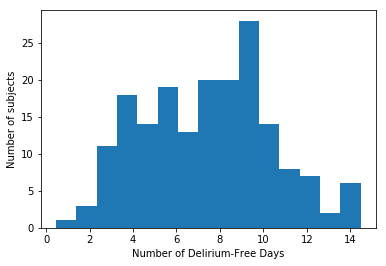

In [139]:
plt.hist(DFDs, bins = 15, align = 'right')
plt.ylabel('Number of subjects')
plt.xlabel('Number of Delirium-Free Days')

plt.savefig(mad3_path + 'CAMICU_hist_check.pdf')

0.32065217391304346


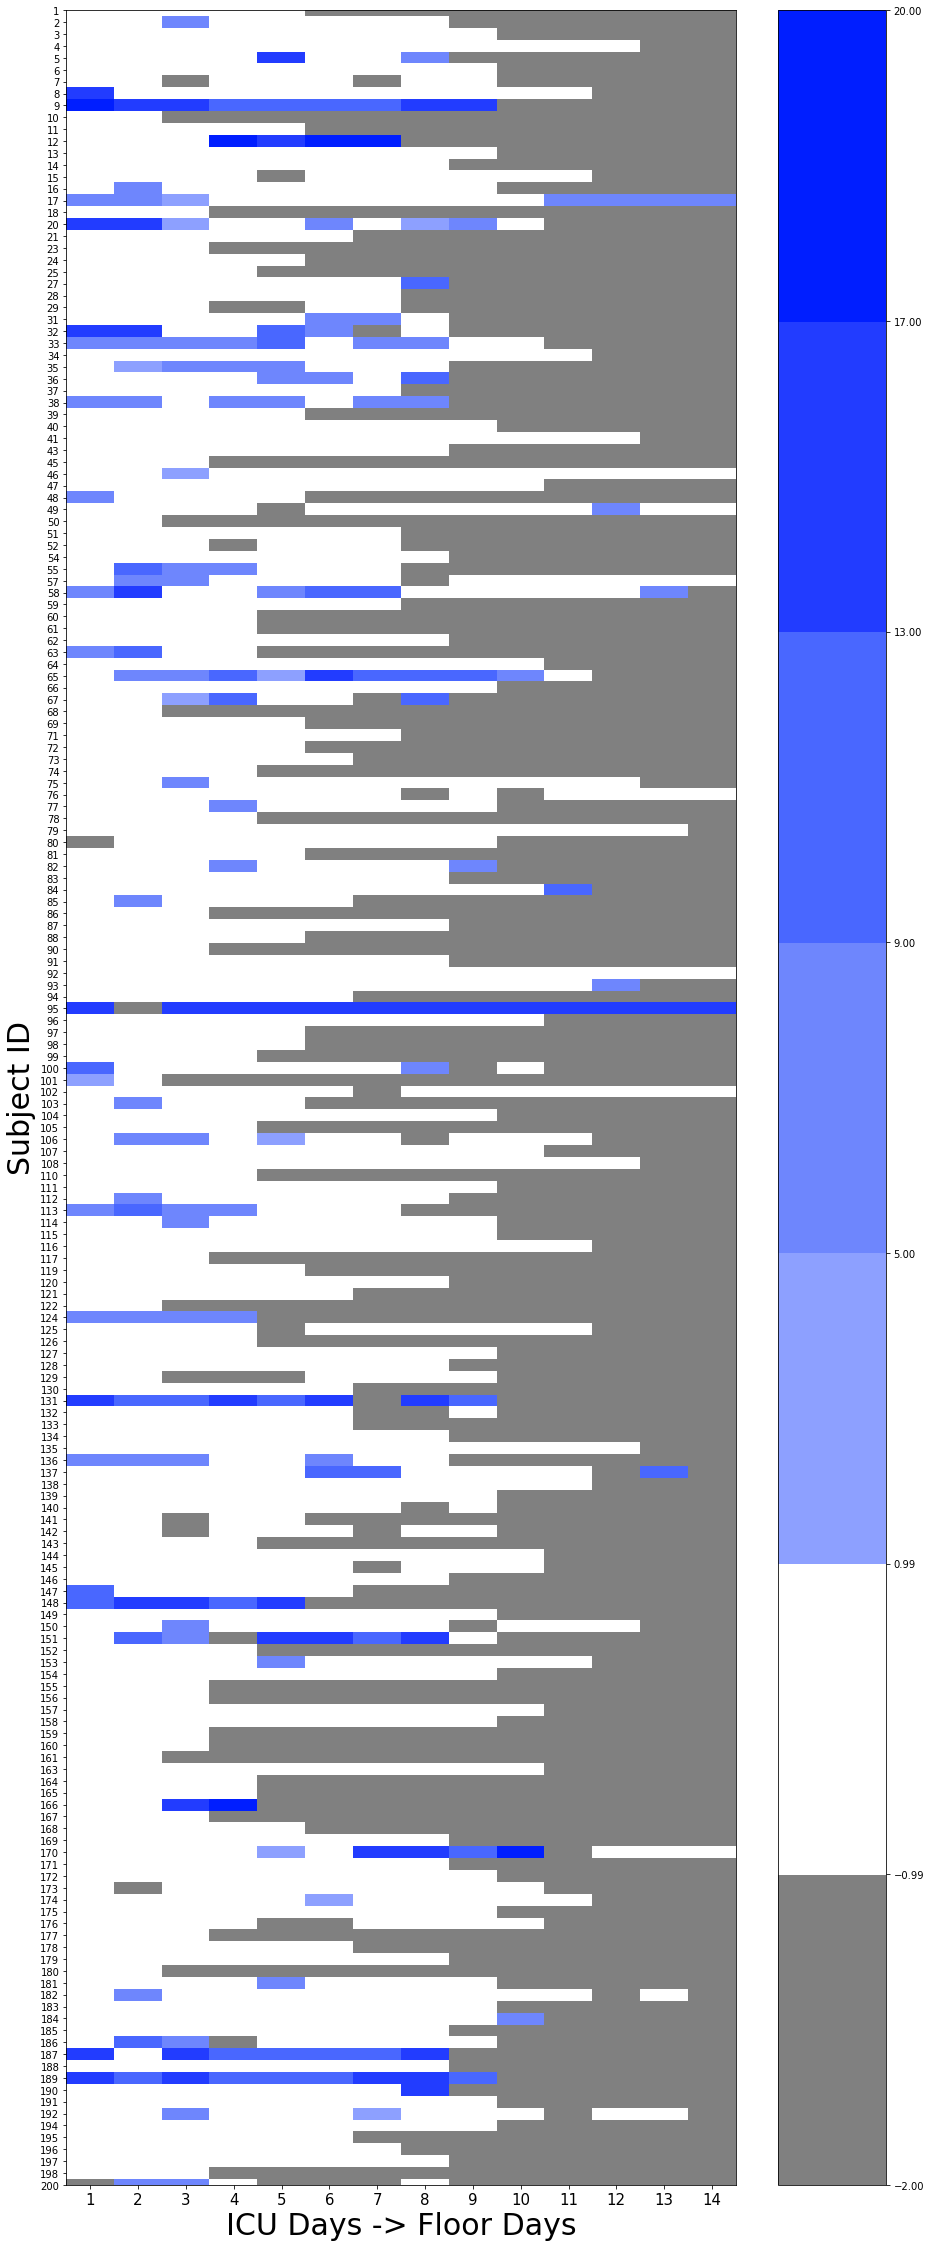

In [11]:
### Swimmer plots - delirium from CAM-S2 (the DSM5 definition of delirium)
swimmer_CAMS2_full = cam_S2_scores_upto14 + (days_included_upto14 - 1)
swimmer_CAMS2_enrolled = swimmer_CAMS2_full[np.asarray(subject_list)-1,:]

num_days_assessed = np.sum(days_included_upto14[np.asarray(subject_list)-1,:], axis = 1)
num_days_delirious = np.sum( (swimmer_CAMS2_full[np.asarray(subject_list)-1,:] >= 1).astype(int), axis = 1)

ever_delirious = np.sum(np.ceil(num_days_delirious/1000))
print(ever_delirious/len(num_days_delirious))

num_days_not_assessed_delirious = np.sum( (cam_S2_scores_upto14[np.asarray(subject_list)-1,:] == 0).astype(int), axis = 1)
num_days_assessed_delirious = np.sum( (cam_S2_scores_upto14[np.asarray(subject_list)-1,:] >= 1).astype(int), axis = 1)

num_days_happened = []
DFDs = []
ii = 0
for subject in subject_list:
    
    days_happened = list(np.flatnonzero(days_included_upto14[subject - 1, :]))[-1] + 1
    num_days_happened.append(  days_happened )
    
    DFDs.append( num_days_assessed[ii] - num_days_assessed_delirious[ii]    )
    
    ii = ii + 1

# make a color map of fixed colors
from matplotlib import colors
cmap = colors.ListedColormap(['grey', 'white', '#8da0ff', '#6e86fd','#4967ff', '#223cff', '#001eff'])
bounds=[-2,-0.99,0.99, 5, 9, 13, 17, 20]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize = (15,40))
plt.imshow(swimmer_CAMS2_enrolled, cmap=cmap, norm=norm)
ax = plt.gca()
ax.set_aspect('auto')
plt.yticks(range(len(swimmer_CAMS2_enrolled[:,0])), subject_list)
plt.xticks(range(0,14),range(1,15), fontsize = 15)
plt.xlabel('ICU Days -> Floor Days', fontsize = 30)
plt.ylabel('Subject ID', fontsize = 30)
plt.colorbar()
#plt.show()
plt.savefig(mad3_path + 'combined_CAMS2_04022020.pdf')

# print raw data
swimmer_df = pd.DataFrame(swimmer_CAMS2_enrolled, columns=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])
swimmer_df.to_csv(mad3_path  + 'power_calcs_04022020' + '/' + 'swimmer_camS2.csv', index=False )

full_dataset_CAMICU = np.hstack( (np.expand_dims(np.asarray(subject_list), axis = 1 ), 
                                        #np.expand_dims(row_sum_days, axis = 1),
            np.expand_dims(np.asarray(DFDs), axis=1),
                                 np.expand_dims(np.asarray(num_days_happened), axis=1),
                                 np.expand_dims(num_days_assessed, axis=1) ))

df = pd.DataFrame(data=full_dataset_CAMICU, columns=["ID", "delirium_free_days","num_days_admitted", "num_days_assessed"])

df.to_csv(mad3_path  + 'power_calcs_04022020' + '/' + 'camS2_data_DFDs.csv', index=False )


In [16]:
swimmer_df.shape

(184, 14)

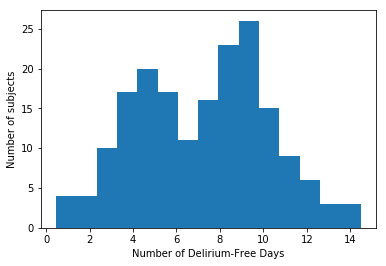

In [141]:
plt.hist(DFDs, bins = 15, align = 'right')
plt.ylabel('Number of subjects')
plt.xlabel('Number of Delirium-Free Days')

plt.savefig(mad3_path + 'CAMS2_hist_check.pdf')

ValueError: shape mismatch: objects cannot be broadcast to a single shape

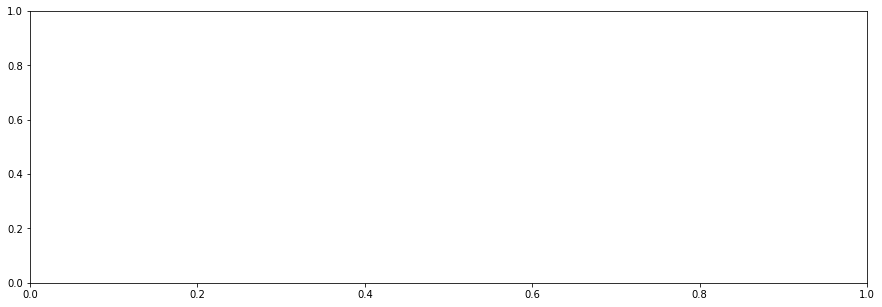

In [17]:
# Version 1: delirium-free days

N = 184
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p2 = plt.bar(ind, icu_delirium_free_days, width, color="blue")
p1 = plt.bar(ind, floor_delirium_free_days, width, bottom=icu_delirium_free_days, color="green")

p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirium-free Days')
plt.title('Documented delirium-free days per subject (CAM-ICU negative)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 14))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

#plt.savefig(mad3_path + 'ICU_delirium_free_days_09032019.png')
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape

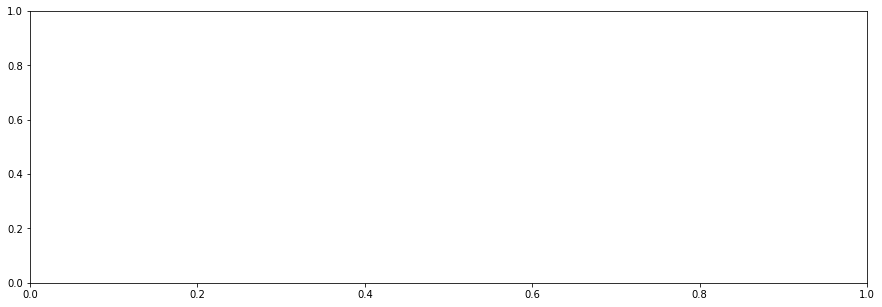

In [12]:

N = 135
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p1 = plt.bar(ind, floor_delirious_days, width, bottom= icu_delirious_days, color="orange")
p2 = plt.bar(ind, icu_delirious_days, width, color="red")
p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirious Days')
plt.title('Days of documented delirium per subject (CAM-ICU positive)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 15))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

#plt.savefig(mad3_path + 'delirious_days_04242019.png')
plt.show()

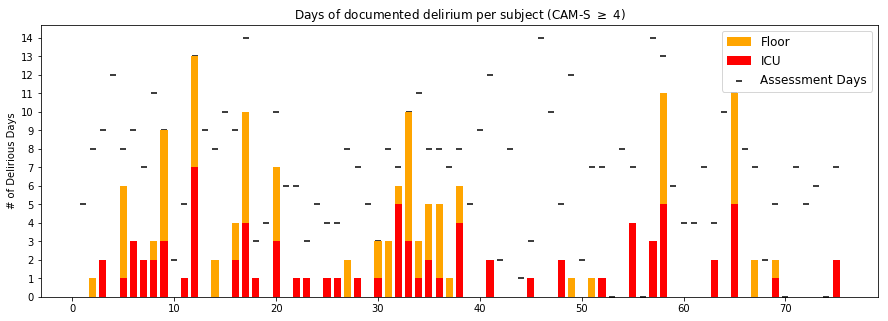

In [16]:
# Version 2: Plot number of delirious days


N = 75
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p1 = plt.bar(ind, floor_delirious_days, width, bottom= icu_delirious_days, color="orange")
p2 = plt.bar(ind, icu_delirious_days, width, color="red")
p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirious Days')
plt.title('Days of documented delirium per subject (CAM-S $\geq$ 4)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 15))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

plt.savefig(mad3_path + 'delirious_days_04022019.png')
plt.show()

[3, 2, 2, 6, 1, 1, 3, 2, 0, 2, 1, 0, 2, 2, 4, 0, 3, 2, 2, 0, 3, 1, 2, 4, 3, 1, 2, 2, 3, 0, 2, 0, 0, 3, 0, 1, 2, 1, 2, 3, 3, 2, 7, 1, 2, 7, 3, 1, 6, 2, 2, 2, 0, 3, 0, 0, 4, 1, 4, 2, 2, 2, 0, 4, 0, 3, 2, 2, 2, 0, 3, 2, 2, 0, 4]

[2, 5, 5, 6, 1, 5, 2, 6, 0, 0, 3, 0, 7, 4, 6, 5, 1, 0, 2, 3, 3, 4, 0, 1, 0, 2, 4, 4, 2, 0, 3, 1, 0, 5, 3, 2, 4, 1, 3, 6, 7, 0, 1, 0, 0, 7, 7, 2, 5, 0, 4, 4, 0, 5, 3, 0, 7, 1, 2, 2, 2, 5, 2, 6, 0, 5, 3, 0, 1, 0, 4, 3, 4, 0, 1]


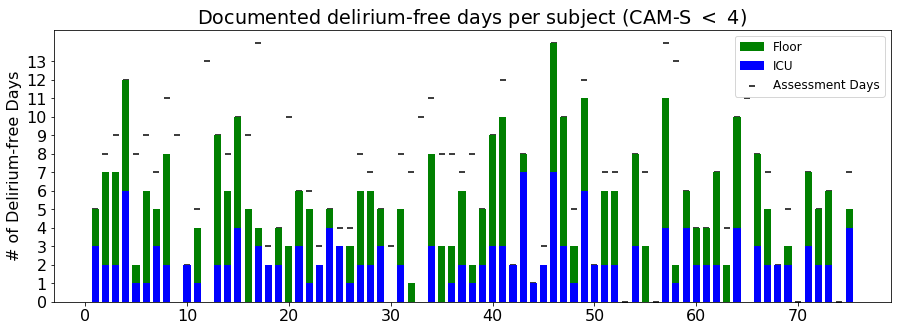

In [18]:
# Version 2: Plot number of delirium-free days
print(icu_delirium_free_days)
print('')
print(floor_delirium_free_days)

N = 75
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p2 = plt.bar(ind, icu_delirium_free_days, width, color="blue")
p1 = plt.bar(ind, floor_delirium_free_days, width, bottom=icu_delirium_free_days, color="green")

p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirium-free Days')
plt.title('Documented delirium-free days per subject (CAM-S $<$ 4)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 14))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

plt.savefig(mad3_path + 'delirium_free_days_04022019.png')
plt.show()

In [29]:
### ICU cam delirium free

print(icu_delirium_free_tuples)
print('')
print(floor_delirium_free_tuples)

d = []
for subject in subject_list:
    ID = str(subject)
    icu_tup = icu_delirium_free_tuples[subject-1]
    icu_delirious_tup = icu_delirious_tuples[subject-1]
    icu_delirium_free_str = str(icu_tup[0]) + '/' + str(icu_tup[1])
    icu_delirious_str = str(icu_delirious_tup[0]) + '/' + str(icu_delirious_tup[1])
    floor_tup = floor_delirium_free_tuples[subject-1]
    floor_delirious_tup = floor_delirious_tuples[subject-1]
    floor_delirium_free_str = str(floor_tup[0]) + '/' + str(floor_tup[1])
    floor_delirious_str = str(floor_delirious_tup[0]) + '/' + str(floor_delirious_tup[1])
    d.append({'Study ID': ID, 'ICU delirium-free days': icu_delirium_free_str,
              'Floor delirium-free days': floor_delirium_free_str, 'ICU delirious days':icu_delirious_str,
              'Floor delirious days':floor_delirious_str})
    
cam_s_output_df = pd.DataFrame(d)
cam_s_output_path = mad3_path + '/CAM-ICU-del-free-2019-09-03.xlsx'
cols = ['Study ID', 'ICU delirious days', 'Floor delirious days', 'ICU delirium-free days','Floor delirium-free days']
cam_s_output_df.to_excel(cam_s_output_path, index = None, columns=cols)

[(3, 3), (2, 2), (4, 4), (6, 6), (2, 2), (4, 4), (5, 5), (3, 4), (0, 3), (2, 2), (2, 2), (3, 7), (2, 2), (2, 2), (4, 4), (2, 2), (7, 7), (3, 3), (2, 2), (1, 3), (3, 3), (2, 2), (3, 3), (4, 4), (3, 3), (2, 2), (2, 2), (3, 3), (2, 2), (1, 1), (2, 2), (3, 5), (2, 3), (4, 4), (2, 2), (2, 2), (2, 2), (5, 5), (2, 2), (3, 3), (4, 5), (2, 2), (7, 7), (1, 1), (3, 3), (7, 7), (3, 3), (2, 3), (6, 6), (2, 2), (2, 2), (2, 2), (0, 0), (3, 3), (4, 4), (3, 3), (7, 7), (3, 5), (4, 4), (2, 2), (2, 2), (2, 2), (2, 2), (4, 4), (3, 5), (3, 3), (2, 2), (2, 2), (3, 3), (0, 0), (3, 3), (2, 2), (2, 2), (4, 4), (6, 6), (7, 7), (2, 2), (2, 2), (6, 6), (2, 2), (2, 2), (2, 2), (3, 3), (4, 4), (2, 2), (2, 2), (2, 2), (2, 2), (1, 1), (3, 3), (2, 2), (7, 7), (5, 5), (3, 3), (0, 6), (3, 3), (2, 2), (4, 4), (2, 2), (0, 2), (2, 2), (6, 6), (2, 2), (3, 3), (3, 3), (7, 7), (3, 3), (4, 4), (1, 1), (1, 1), (2, 2), (5, 5), (0, 1), (3, 4), (3, 3), (4, 4), (1, 1), (0, 0), (0, 0), (4, 4), (2, 2), (2, 2), (2, 2), (2, 2), (4, 4),

In [20]:
### delirium-free ; ignore for now. We are doing days of delirium

print(icu_delirium_free_tuples)
print('')
print(floor_delirium_free_tuples)

d = []
for subject in subject_list:
    ID = str(subject)
    icu_tup = icu_delirium_free_tuples[subject-1]
    icu_delirious_tup = icu_delirious_tuples[subject-1]
    icu_delirium_free_str = str(icu_tup[0]) + '/' + str(icu_tup[1])
    icu_delirious_str = str(icu_delirious_tup[0]) + '/' + str(icu_delirious_tup[1])
    floor_tup = floor_delirium_free_tuples[subject-1]
    floor_delirious_tup = floor_delirious_tuples[subject-1]
    floor_delirium_free_str = str(floor_tup[0]) + '/' + str(floor_tup[1])
    floor_delirious_str = str(floor_delirious_tup[0]) + '/' + str(floor_delirious_tup[1])
    d.append({'Study ID': ID, 'ICU delirium-free days': icu_delirium_free_str,
              'Floor delirium-free days': floor_delirium_free_str, 'ICU delirious days':icu_delirious_str,
              'Floor delirious days':floor_delirious_str})
    
cam_s_output_df = pd.DataFrame(d)
cam_s_output_path = mad3_path + '/CAM-S-del-free-2019-04-24.xlsx'
cols = ['Study ID', 'ICU delirious days', 'Floor delirious days', 'ICU delirium-free days','Floor delirium-free days']
cam_s_output_df.to_excel(cam_s_output_path, index = None, columns=cols)

[(3, 3), (2, 2), (2, 4), (6, 6), (1, 2), (1, 4), (3, 5), (2, 4), (0, 3), (2, 2), (1, 2), (0, 7), (2, 2), (2, 2), (4, 4), (0, 2), (3, 7), (2, 3), (2, 2), (0, 3), (3, 3), (1, 2), (2, 3), (4, 4), (3, 4), (1, 2), (2, 2), (2, 3), (3, 3), (0, 1), (2, 2), (0, 5), (0, 3), (3, 4), (0, 2), (1, 2), (2, 2), (1, 5), (2, 2), (3, 3), (3, 5), (2, 2), (7, 7), (1, 1), (2, 3), (7, 7), (3, 3), (1, 3), (6, 6), (2, 2), (2, 2), (2, 3), (0, 0), (3, 3), (0, 4), (0, 0), (4, 7), (1, 6), (4, 4), (2, 2), (2, 2), (2, 2), (0, 2), (4, 4), (0, 5), (3, 3), (2, 2), (2, 2), (2, 3), (0, 0), (3, 3), (2, 2), (2, 2), (0, 0), (4, 6)]

[(2, 2), (5, 6), (5, 5), (6, 6), (1, 6), (5, 5), (2, 2), (6, 7), (0, 6), (0, 0), (3, 3), (0, 6), (7, 7), (4, 6), (6, 6), (5, 7), (1, 7), (0, 0), (2, 2), (3, 7), (3, 3), (4, 4), (0, 0), (1, 1), (0, 0), (2, 2), (4, 6), (4, 4), (2, 2), (0, 2), (3, 6), (1, 2), (0, 7), (5, 7), (3, 6), (2, 6), (4, 5), (1, 3), (3, 3), (6, 6), (7, 7), (0, 0), (1, 1), (0, 0), (0, 0), (7, 7), (7, 7), (2, 2), (5, 6), (0, 0